# COE 311K Midterm Project
## Curve Fitting & Interpolation Project: U.S. GDP Growth Rate Analysis

In this project, I analyzed selected U.S. quarterly GDP growth rate data from 2010 to 2023 using consecutive integer quarter indices as the independent variable and three numerical methods: natural cubic spline interpolation, degree-4 polynomial fitting, and least squares linear regression. The dataset comes from the U.S. Bureau of Economic Analysis and includes several normal GDP values along with the extreme COVID-period quarters. The goal of this project is to compare interpolation versus approximation, study how outliers affect each method, and decide which method is most appropriate for trend analysis versus estimating values between known data points. 

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# GDP DATA
# x has to be consecutive integer quarter indices
# so i am using 1, 2, 3, ... instead of raw year values

quarters = [
    "2010 Q1", "2011 Q1", "2012 Q1", "2013 Q1", "2014 Q1",
    "2014 Q3", "2015 Q2", "2016 Q1", "2016 Q3", "2016 Q4",
    "2017 Q1", "2018 Q1", "2019 Q1", "2020 Q1", "2020 Q2",
    "2020 Q3", "2021 Q1", "2022 Q1", "2023 Q2", "2023 Q4"
]

y = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7,
    5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1,
    33.8, 6.3, -1.6, 2.4, 3.3
], dtype=float)

x = np.arange(1, len(y) + 1, dtype=float)


# helper funcs
# just putting the little utility stuff here so the main parts look cleaner
# found this method always simplifies the work

def mse(y_true, y_pred):
    # mean squared error
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    # root mean squared error
    return np.sqrt(mse(y_true, y_pred))

def r_squared(y_true, y_pred):
    # R^2 = 1 - SSres / SStot
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def get_residuals(y_true, y_pred):
    # residual = actual - predicted
    return y_true - y_pred


## Part A: Cubic Spline Interpolation

1. In this part, I constructed a natural cubic spline through all of the provided GDP data points. For a natural spline with \(n\) data points, the unknowns are the second derivatives at the interior knots, so there are \(n-2\) unknowns. The spline must satisfy continuity of the function, first derivative, and second derivative at each interior knot. The natural boundary conditions set the second derivative equal to zero at the two endpoints.

2. After solving the tridiagonal system, I evaluated the spline over a smooth set of quarter indices and plotted the result. The spline is visually smooth and passes exactly through every data point, including the extreme values in 2020 Q2 and 2020 Q3. This makes it very accurate for interpolation, but it also means the spline is forced to react strongly to unusual outliers. 

PART A: NATURAL CUBIC SPLINE
Spline RMSE on data = 1.589609576479376e-15
Spline R^2 on data  = 1.0



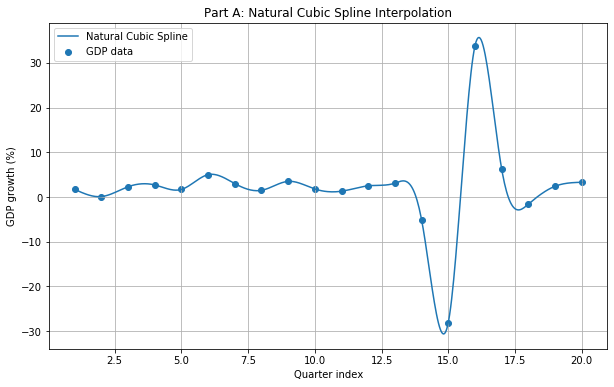

In [11]:
# for the spline, i am doing the natural cubic spline
# that means the second derivative at the two endpoints is 0
# i am building the tridiagonal system then solving it

def natural_cubic_spline_second_derivs(x, y):
    # this solves for the second derivatives M0, M1, ..., Mn-1
    # natural spline means M0 = 0 and M(n-1) = 0

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    if n < 3:
        raise ValueError("need at least 3 points for a cubic spline")

    # h values = spacing between x values
    h = np.diff(x)

    # the interior system has size (n-2) x (n-2)
    # these are the unknown second derivatives at the interior knots
    m = n - 2

    # tridiagonal pieces
    lower = np.zeros(m)   # subdiagonal
    diag = np.zeros(m)    # main diagonal
    upper = np.zeros(m)   # superdiagonal
    rhs = np.zeros(m)     # right-hand side

    # build the system row by row
    for j in range(m):
        i = j + 1  # actual interior point index

        # main diagonal part
        diag[j] = 2 * (h[i - 1] + h[i])

        # right-hand side is based on slope changes
        rhs[j] = 6 * (
            (y[i + 1] - y[i]) / h[i]
            - (y[i] - y[i - 1]) / h[i - 1]
        )

        # left off-diagonal
        if j > 0:
            lower[j] = h[i - 1]

        # right off-diagonal
        if j < m - 1:
            upper[j] = h[i]

    # turn the tridiagonal pieces into a full matrix
    T = np.zeros((m, m))

    for i in range(m):
        T[i, i] = diag[i]
        if i > 0:
            T[i, i - 1] = lower[i]
        if i < m - 1:
            T[i, i + 1] = upper[i]

    # solve for the interior second derivatives
    M_interior = np.linalg.solve(T, rhs)

    #  put back the natural boundary conditions
    M = np.zeros(n)
    M[1:-1] = M_interior

    return M


def eval_natural_cubic_spline(x_data, y_data, M, x_eval):
    # this evaluates the spline at any x values i want
    # it figures out which interval each x is in and uses the cubic spline formula there

    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)
    M = np.asarray(M, dtype=float)
    x_eval = np.asarray(x_eval, dtype=float)

    y_eval = np.zeros_like(x_eval, dtype=float)

    for k, xv in enumerate(x_eval):
        # figure out which interval xv belongs to
        if xv <= x_data[0]:
            i = 0
        elif xv >= x_data[-1]:
            i = len(x_data) - 2
        else:
            i = np.searchsorted(x_data, xv) - 1

        xi = x_data[i]
        xi1 = x_data[i + 1]
        h = xi1 - xi

        # cubic spline formula on [xi, xi+1]
        term1 = M[i] * (xi1 - xv) ** 3 / (6 * h)
        term2 = M[i + 1] * (xv - xi) ** 3 / (6 * h)
        term3 = (y_data[i] - M[i] * h ** 2 / 6) * (xi1 - xv) / h
        term4 = (y_data[i + 1] - M[i + 1] * h ** 2 / 6) * (xv - xi) / h

        y_eval[k] = term1 + term2 + term3 + term4

    return y_eval


# build and evaluate the natural spline
M = natural_cubic_spline_second_derivs(x, y)

# smooth x values so the curve looks nice
x_smooth = np.linspace(x.min(), x.max(), 500)
y_spline_smooth = eval_natural_cubic_spline(x, y, M, x_smooth)

# spline evaluated at the original data points
# this should match the data exactly because spline is interpolation
y_spline_data = eval_natural_cubic_spline(x, y, M, x)

print("PART A: NATURAL CUBIC SPLINE")
print("Spline RMSE on data =", rmse(y, y_spline_data))
print("Spline R^2 on data  =", r_squared(y, y_spline_data))
print()

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="GDP data")
plt.plot(x_smooth, y_spline_smooth, label="Natural Cubic Spline")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Part A: Natural Cubic Spline Interpolation")
plt.legend()
plt.grid(True)
plt.show()


### 3. Discussion of Outliers and Runge Phenomenon

One important issue in this dataset is the presence of extreme outliers during the COVID period, especially 2020 Q2 and 2020 Q3. Because cubic spline interpolation is an exact interpolation method, it must pass directly through these values. This can make the curve bend sharply near those quarters, even if the rest of the data behaves more moderately.

This connects to the general idea behind the Runge phenomenon, where exact interpolation, especially with global polynomials, can create oscillations and numerical instability when data contains strong variation or extreme points. Splines are usually much more stable than one high-degree global polynomial because they are piecewise and local, but they still must honor the outliers exactly.

For data like this, a smoothing spline or weighted least squares approach could sometimes be preferable if the goal is to reduce the influence of extreme points and capture a broader economic trend. A smoothing spline would allow a small amount of error in exchange for a more stable curve, while weighted least squares could reduce the effect of unusual quarters by assigning them less influence. 

## Part B: Polynomial and Least Squares Comparison

1. First, I fit a degree-4 polynomial to the GDP data using a Vandermonde matrix and the normal equations. I also fit a least squares linear model after excluding the COVID quarters from 2020 Q1 through 2021 Q1, since those values are extreme outliers relative to the rest of the dataset. Unlike the cubic spline, the polynomial does not have to pass exactly through every point. Instead, it gives an approximation that tries to capture the overall shape of the dataset. 

 When I compared the degree-4 polynomial to the cubic spline, the polynomial acted more like a broad approximation of the data, while the spline reproduced the exact values at the given quarters. In this dataset, the extreme COVID-period values make the polynomial fit less accurate overall, which can be seen in its relatively large RMSE and very low \(R^2\). This highlights the trade-off between approximation and interpolation. The spline is better when exact point-to-point behavior matters, while the polynomial is better when the goal is to represent the broader pattern without matching every value exactly.

DEGREE-4 POLYNOMIAL
Polynomial coefficients = [-4.13737100e+00  4.44241917e+00 -8.23719896e-01  5.44711952e-02
 -1.17213791e-03]
Polynomial RMSE = 9.96532678651953
Polynomial R^2  = 0.016632392138785312



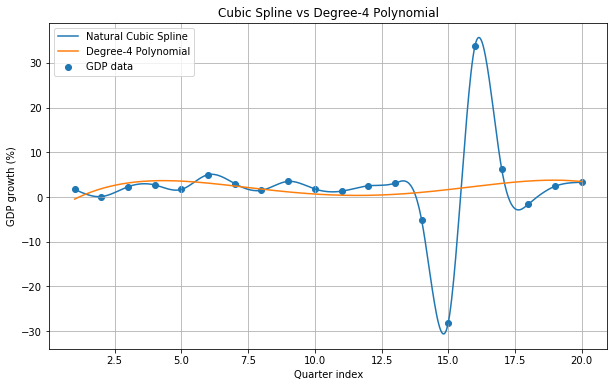

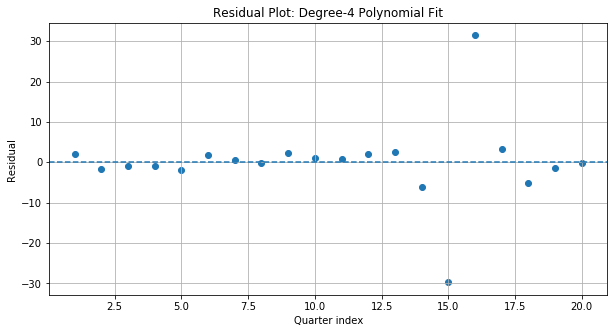

In [12]:
# PART B: POLYNOMIAL FITTING & LEAST SQUARES
# Two things here:
# - degree-4 polynomial fit using a Vandermonde matrix
# - least squares linear fit excluding the COVID quarters
# no polyfit here because the project says not to use built-in curve fitting

def create_vandermonde_matrix(x, degree):
    # columns are 1, x, x^2,
    x = np.asarray(x, dtype=float)
    return np.vander(x, N=degree + 1, increasing=True)

def polynomial_fit_normal_eq(x, y, degree):
    # build Vandermonde matrix and solve the normal equations
    # (V^T V)a = V^T y

    V = create_vandermonde_matrix(x, degree)
    A = V.T @ V
    b_vec = V.T @ y

    coeffs = np.linalg.solve(A, b_vec)
    return coeffs

def eval_polynomial(x, coeffs):
    # manually evaluate the polynomial from the coefficient vector
    # coeffs[0] + coeffs[1]x + coeffs[2]x^2 + ...
    x = np.asarray(x, dtype=float)
    y_pred = np.zeros_like(x, dtype=float)

    for j, a_j in enumerate(coeffs):
        y_pred += a_j * x ** j

    return y_pred

def least_squares_line(x, y):
    # my own least squares line using the formula version
    # line is y = mx + b

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    Sx = np.sum(x)
    Sy = np.sum(y)
    Sxx = np.sum(x * x)
    Sxy = np.sum(x * y)

    denom = n * Sxx - Sx ** 2
    if np.isclose(denom, 0.0):
        raise ValueError("denominator is too close to 0")

    m = (n * Sxy - Sx * Sy) / denom
    b = (Sy - m * Sx) / n

    return m, b

def eval_line(x, m, b):
    # plug into y = mx + b
    return m * x + b

# degree-4 polynomial

degree = 4
coeffs_poly4 = polynomial_fit_normal_eq(x, y, degree)

y_poly4_data = eval_polynomial(x, coeffs_poly4)
y_poly4_smooth = eval_polynomial(x_smooth, coeffs_poly4)

# compare spline and polynomial on the same figure
print("DEGREE-4 POLYNOMIAL")
print("Polynomial coefficients =", coeffs_poly4)
print("Polynomial RMSE =", rmse(y, y_poly4_data))
print("Polynomial R^2  =", r_squared(y, y_poly4_data))
print()

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="GDP data")
plt.plot(x_smooth, y_spline_smooth, label="Natural Cubic Spline")
plt.plot(x_smooth, y_poly4_smooth, label="Degree-4 Polynomial")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Cubic Spline vs Degree-4 Polynomial")
plt.legend()
plt.grid(True)
plt.show()


# residual plot for the polynomial fit
poly_res = get_residuals(y, y_poly4_data)

plt.figure(figsize=(10, 5))
plt.axhline(0, linestyle="--")
plt.scatter(x, poly_res)
plt.xlabel("Quarter index")
plt.ylabel("Residual")
plt.title("Residual Plot: Degree-4 Polynomial Fit")
plt.grid(True)
plt.show()


### Least Squares Linear Model Excluding COVID Quarters

Next, I fit a least squares linear model after excluding the COVID-period quarters from 2020 Q1 through 2021 Q1. I removed those values because they represent a major economic shock and recovery, and including them would distort the long-term trend. The slope of the fitted line represents the average change in GDP growth per quarter index over the remaining data. The slope of approximately \(-0.0173\) suggests a very slight downward average trend in GDP growth per quarter index after removing the COVID-period quarters. However, because the slope is small and the \(R^2\) value is very close to zero, the linear model should be viewed as only a rough summary rather than strong evidence of a meaningful long-term linear trend.

A linear trend is useful because it is simple and easy to interpret, but it does not fully capture the ups and downs of economic growth. For a linear model to make sense here, it assumes that the overall pattern changes at a roughly constant rate and that the excluded COVID values are temporary disruptions rather than part of the long-term trend. In reality, GDP growth is more complex than a straight line, so the linear model is best viewed as a rough summary rather than a detailed representation of the data. 

LEAST SQUARES LINE EXCLUDING COVID QUARTERS
Slope = -0.0173364485981308
Intercept = 2.3041121495327097
Linear RMSE = 1.4400212550352411
Linear R^2  = 0.004822992655011293



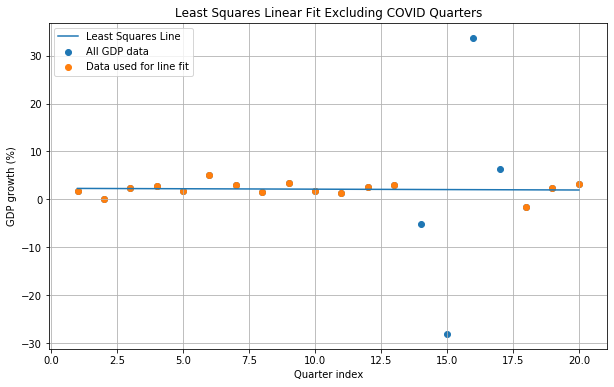

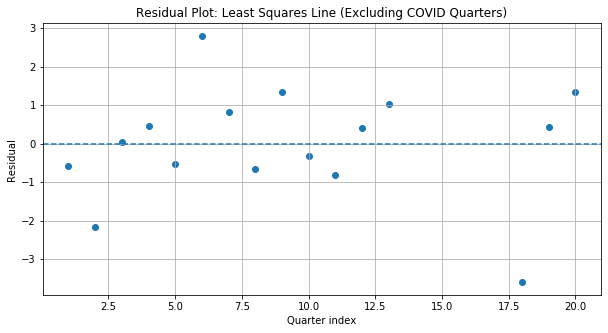

In [13]:

# Least squares line excluding COVID quarters
# the project says to exclude 2020 Q1 through 2021 Q1

mask = np.ones(len(x), dtype=bool)
mask[13:17] = False

x_no_covid = x[mask]
y_no_covid = y[mask]

m_line, b_line = least_squares_line(x_no_covid, y_no_covid)

y_line_data = eval_line(x_no_covid, m_line, b_line)
y_line_smooth = eval_line(x_smooth, m_line, b_line)

print("LEAST SQUARES LINE EXCLUDING COVID QUARTERS")
print("Slope =", m_line)
print("Intercept =", b_line)
print("Linear RMSE =", rmse(y_no_covid, y_line_data))
print("Linear R^2  =", r_squared(y_no_covid, y_line_data))
print()

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="All GDP data")
plt.scatter(x_no_covid, y_no_covid, label="Data used for line fit")
plt.plot(x_smooth, y_line_smooth, label="Least Squares Line")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Least Squares Linear Fit Excluding COVID Quarters")
plt.legend()
plt.grid(True)
plt.show()


# residual plot for the least squares line
line_res = get_residuals(y_no_covid, y_line_data)

plt.figure(figsize=(10, 5))
plt.axhline(0, linestyle="--")
plt.scatter(x_no_covid, line_res)
plt.xlabel("Quarter index")
plt.ylabel("Residual")
plt.title("Residual Plot: Least Squares Line (Excluding COVID Quarters)")
plt.grid(True)
plt.show()

## Part C:  Method Justification
In this part, I compare the three methods using both quantitative metrics and qualitative reasoning. The spline is best for interpolation between known data points because it is smooth and passes exactly through the data. The polynomial is better for capturing an overall trend than exact point-by-point behavior, while the linear model gives the simplest broad trend after removing the extreme COVID-period disturbances.

For a policymaker who needs to estimate GDP growth for a quarter between two known data points, I would recommend the cubic spline instead of polynomial fitting. The main reason is that the spline is specifically designed for interpolation. It is smooth, piecewise, and local, so it gives a more reliable estimate between nearby known values.

A polynomial fit can be useful for understanding the overall trend, but it is a global model, which means one unusual region of the data can affect the curve everywhere. That makes it more sensitive to outliers and less trustworthy for local interpolation. In contrast, the cubic spline preserves smoothness while staying closely tied to the surrounding data points, which makes it the better choice for estimating values between known quarters. This is also supported by the numerical results. The cubic spline has an RMSE near zero and an \(R^2\) of 1, meaning it perfectly matches the data. In contrast, the degree-4 polynomial and linear model both have very low \(R^2\) values, showing that they do not capture the data nearly as well.

PART C: COMPARISON SUMMARY
Spline RMSE on original data = 1.589609576479376e-15
Spline R^2 on original data  = 1.0

Degree-4 Polynomial RMSE = 9.96532678651953
Degree-4 Polynomial R^2  = 0.016632392138785312

Least Squares Line RMSE (excluding COVID) = 1.4400212550352411
Least Squares Line R^2  (excluding COVID) = 0.004822992655011293



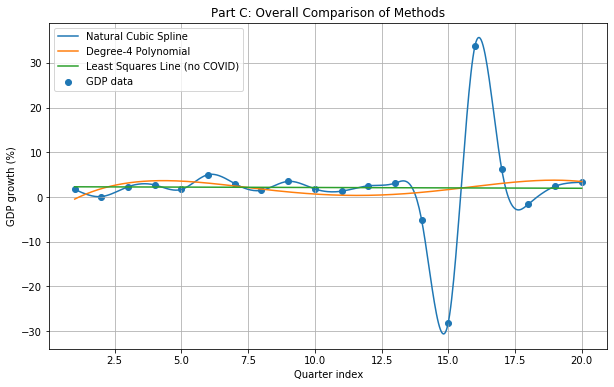

In [14]:
# PART C: METHOD JUSTIFICATION
# i am printing out a few metrics here so it is easier to talk about 

print("PART C: COMPARISON SUMMARY")
print("Spline RMSE on original data =", rmse(y, y_spline_data))
print("Spline R^2 on original data  =", r_squared(y, y_spline_data))
print()

print("Degree-4 Polynomial RMSE =", rmse(y, y_poly4_data))
print("Degree-4 Polynomial R^2  =", r_squared(y, y_poly4_data))
print()

print("Least Squares Line RMSE (excluding COVID) =", rmse(y_no_covid, y_line_data))
print("Least Squares Line R^2  (excluding COVID) =", r_squared(y_no_covid, y_line_data))
print()

# comparison plot with all three on one figure
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="GDP data")
plt.plot(x_smooth, y_spline_smooth, label="Natural Cubic Spline")
plt.plot(x_smooth, y_poly4_smooth, label="Degree-4 Polynomial")
plt.plot(x_smooth, y_line_smooth, label="Least Squares Line (no COVID)")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Part C: Overall Comparison of Methods")
plt.legend()
plt.grid(True)
plt.show()

### Computational Cost and Big-O Analysis

Big-O notation is used to describe how the computational cost of an algorithm grows as the size of the input increases. In this project, the input size is the number of data points \(n\).

For the natural cubic spline, we construct and solve a tridiagonal system of size \(n-2\). Solving this system using a general linear solver has a cost of approximately \(O(n^3)\), although specialized tridiagonal solvers can reduce this to \(O(n)\). After solving, evaluating the spline at each point is \(O(n)\).

For the polynomial fit using the Vandermonde matrix, constructing the matrix is \(O(n \cdot d)\), where \(d\) is the degree. Forming the normal equations and solving them has a cost of approximately \(O(d^3)\), but since \(d = 4\) is fixed, this is effectively constant. Overall, the dominant cost is building the matrix, which is \(O(n)\).

For the least squares linear fit, the computations involve summations over the data, so the cost is \(O(n)\). This makes it the most computationally efficient method.

In terms of computational expense, the least squares linear model is the cheapest, followed by the polynomial fit, and then the cubic spline if using a full solver. However, this does not change my recommendation. The cubic spline is still the best choice for interpolation because of its smoothness and local accuracy, even though it is more computationally expensive. Since the dataset in this project is relatively small, the difference in cost is negligible, so accuracy and behavior matter more than runtime.

## Conclusion

In this project, I used natural cubic spline interpolation, degree-4 polynomial fitting, and least squares linear regression to analyze U.S. GDP growth data. Each method had a different strength. The cubic spline was the best method for interpolation because it passed exactly through the data points and produced a smooth curve between them. The degree-4 polynomial was intended to capture the overall trend without matching every point exactly, while the least squares linear model provided the simplest summary of the long-term trend after excluding the extreme COVID-period quarters.

This is supported by the numerical results, where the spline achieved nearly zero error while the polynomial and linear models had much lower \(R^2\) values. Overall, this project showed the difference between interpolation and approximation very clearly. It also demonstrated how strongly outliers can affect fitted models and why the choice of method depends on the purpose of the analysis. For exact estimation between known points, the spline is the strongest choice, while for broader trend analysis, the polynomial or linear fit is more appropriate.